In [1]:
!pip install biopython pandas numpy matplotlib seaborn scikit-learn biotite

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 19.9 MB/s eta 0:00:00


In [2]:
from Bio.PDB import PDBList

pdb_id = "1HSG"

pdbl = PDBList()
file_path = pdbl.retrieve_pdb_file(
    pdb_id,
    pdir=".",
    file_format="pdb"
)

print("Downloaded:", file_path)

Downloaded: ./pdb1hsg.ent


In [3]:
from Bio.PDB import PDBParser

parser = PDBParser(QUIET=True)
structure = parser.get_structure("1HSG", file_path)

ligands = []

for model in structure:
    for chain in model:
        for residue in chain:
            if residue.id[0].startswith("H_"):
                ligands.append((chain.id, residue.resname, residue.id[1]))

print("Ligands found:")
for ligand in ligands:
    print(ligand)

Ligands found:
('B', 'MK1', 902)


In [4]:
from Bio.PDB import NeighborSearch

# Get the ligand
ligand = structure[0]["B"][("H_MK1", 902, " ")]

# Get all protein atoms
protein_atoms = []

for chain in structure[0]:
    for residue in chain:
        if residue.id[0] == " ":
            for atom in residue:
                protein_atoms.append(atom)

# Find protein atoms within 5 Å of the ligand
ns = NeighborSearch(protein_atoms)

nearby_atoms = ns.search(
    ligand["C1"].coord,
    5.0,
    level="A"
)

# Get unique nearby residues
nearby_residues = {}

for atom in nearby_atoms:
    residue = atom.get_parent()
    key = (residue.get_parent().id, residue.id[1], residue.resname)
    nearby_residues[key] = residue

print("Nearby protein residues within 5 Å:")

for key in sorted(nearby_residues):
    print(key)

Nearby protein residues within 5 Å:
('A', 27, 'GLY')
('A', 48, 'GLY')
('A', 49, 'GLY')
('A', 50, 'ILE')


In [5]:
from Bio.PDB import NeighborSearch

results = []

for key, residue in nearby_residues.items():
    min_distance = float("inf")
    closest_atom_pair = None

    for protein_atom in residue:
        for ligand_atom in ligand:
            distance = protein_atom - ligand_atom

            if distance < min_distance:
                min_distance = distance
                closest_atom_pair = (
                    protein_atom.get_name(),
                    ligand_atom.get_name()
                )

    results.append({
        "Chain": key[0],
        "Residue": key[2],
        "Position": key[1],
        "Distance_Angstrom": round(min_distance, 3),
        "Protein_Atom": closest_atom_pair[0],
        "Ligand_Atom": closest_atom_pair[1]
    })

import pandas as pd

distance_df = pd.DataFrame(results)

distance_df = distance_df.sort_values("Distance_Angstrom")

print(distance_df.to_string(index=False))

Chain Residue  Position  Distance_Angstrom Protein_Atom Ligand_Atom
    A     GLY        48              3.149            O         C36
    A     GLY        49              3.548           CA          O1
    A     GLY        27              3.576            O         C10
    A     ILE        50              4.211          CG1         C29


In [6]:
# Create interaction features

interaction_df = distance_df.copy()

interaction_df["Interaction_Type"] = interaction_df["Residue"].map({
    "GLY": "Backbone/close-contact",
    "ILE": "Hydrophobic"
})

interaction_df["Close_Contact"] = (
    interaction_df["Distance_Angstrom"] <= 4.0
).astype(int)

print("Protein-Ligand Interaction Features:")
display(interaction_df)

Protein-Ligand Interaction Features:


,Chain,Residue,Position,Distance_Angstrom,Protein_Atom,Ligand_Atom,Interaction_Type,Close_Contact
2,A,GLY,48,3.149,O,C36,Backbone/close-contact,1
0,A,GLY,49,3.548,CA,O1,Backbone/close-contact,1
3,A,GLY,27,3.576,O,C10,Backbone/close-contact,1
1,A,ILE,50,4.211,CG1,C29,Hydrophobic,0


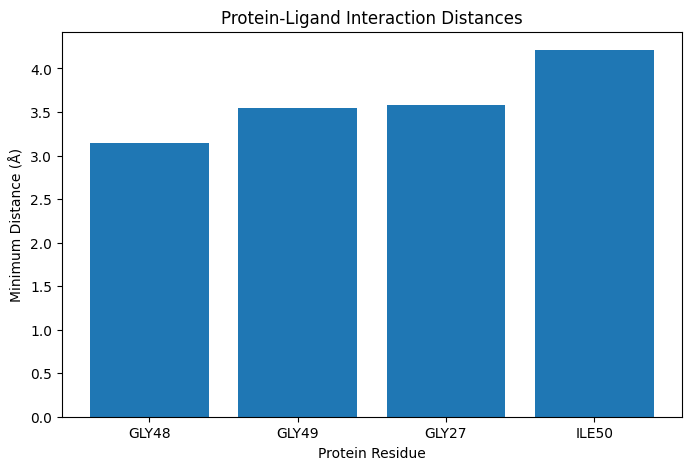

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

labels = interaction_df["Residue"] + interaction_df["Position"].astype(str)
distances = interaction_df["Distance_Angstrom"]

plt.bar(labels, distances)

plt.xlabel("Protein Residue")
plt.ylabel("Minimum Distance (Å)")
plt.title("Protein-Ligand Interaction Distances")

plt.show()

In [8]:
# Simulate mutation effects on interaction residues

mutation_data = interaction_df.copy()

mutation_data["Mutation"] = mutation_data["Residue"] + " -> ALA"

# Simple mutation-impact score based on interaction distance
mutation_data["Interaction_Strength"] = 1 / mutation_data["Distance_Angstrom"]

mutation_data["Mutation_Impact"] = (
    mutation_data["Interaction_Strength"] * mutation_data["Close_Contact"]
)

print("Mutation Analysis:")
display(
    mutation_data[
        [
            "Residue",
            "Position",
            "Distance_Angstrom",
            "Mutation",
            "Interaction_Strength",
            "Mutation_Impact"
        ]
    ]
)

Mutation Analysis:


,Residue,Position,Distance_Angstrom,Mutation,Interaction_Strength,Mutation_Impact
2,GLY,48,3.149,GLY -> ALA,0.317561,0.317561
0,GLY,49,3.548,GLY -> ALA,0.281849,0.281849
3,GLY,27,3.576,GLY -> ALA,0.279642,0.279642
1,ILE,50,4.211,ILE -> ALA,0.237473,0.000000


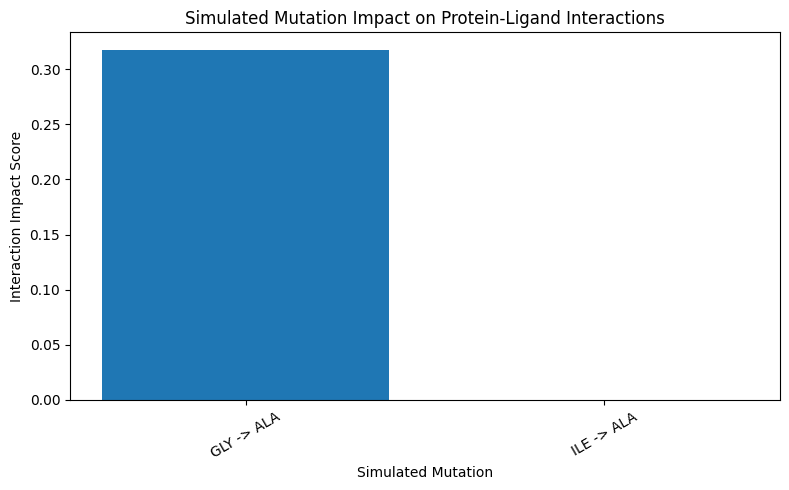

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

labels = mutation_data["Mutation"]
impact = mutation_data["Mutation_Impact"]

plt.bar(labels, impact)

plt.xlabel("Simulated Mutation")
plt.ylabel("Interaction Impact Score")
plt.title("Simulated Mutation Impact on Protein-Ligand Interactions")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

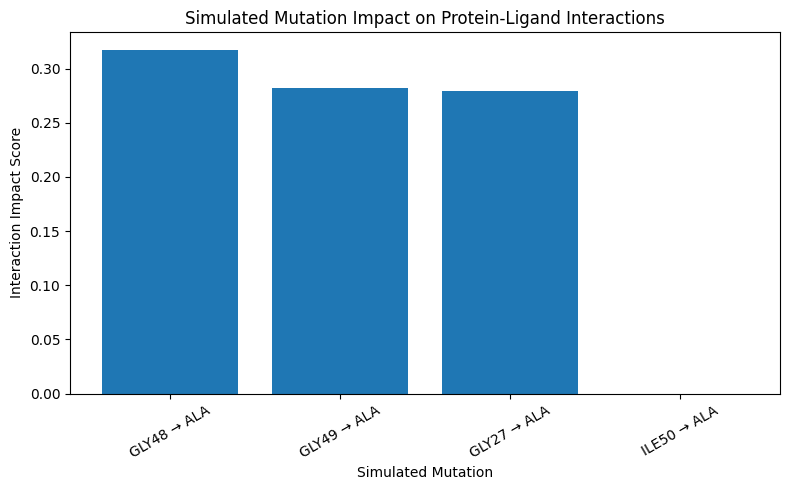

In [10]:
import matplotlib.pyplot as plt

labels = (
    mutation_data["Residue"]
    + mutation_data["Position"].astype(str)
    + " → ALA"
)

impact = mutation_data["Mutation_Impact"]

plt.figure(figsize=(8, 5))
plt.bar(labels, impact)

plt.xlabel("Simulated Mutation")
plt.ylabel("Interaction Impact Score")
plt.title("Simulated Mutation Impact on Protein-Ligand Interactions")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [11]:
# Download multiple protein-ligand complexes

from Bio.PDB import PDBList

pdb_ids = ["1HSG", "1M17", "3ERT", "4AKE", "1TQN"]

pdbl = PDBList()

downloaded_files = {}

for pdb_id in pdb_ids:
    file_path = pdbl.retrieve_pdb_file(
        pdb_id,
        pdir=".",
        file_format="pdb"
    )
    downloaded_files[pdb_id] = file_path

print("Downloaded structures:")
for pdb_id, path in downloaded_files.items():
    print(pdb_id, "->", path)

Structure exists: './pdb1hsg.ent' 
Downloaded structures:
1HSG -> ./pdb1hsg.ent
1M17 -> ./pdb1m17.ent
3ERT -> ./pdb3ert.ent
4AKE -> ./pdb4ake.ent
1TQN -> ./pdb1tqn.ent


In [12]:
from Bio.PDB import PDBParser

parser = PDBParser(QUIET=True)

all_ligands = {}

for pdb_id, file_path in downloaded_files.items():
    structure_temp = parser.get_structure(pdb_id, file_path)

    ligands_found = []

    for model in structure_temp:
        for chain in model:
            for residue in chain:
                if residue.id[0].startswith("H_"):
                    ligands_found.append(
                        (chain.id, residue.resname, residue.id[1])
                    )

    all_ligands[pdb_id] = ligands_found

print("Ligands found in each structure:\n")

for pdb_id, ligands in all_ligands.items():
    print(pdb_id, ":", ligands)

Ligands found in each structure:

1HSG : [('B', 'MK1', 902)]
1M17 : [('A', 'AQ4', 999)]
3ERT : [('A', 'OHT', 600)]
4AKE : []
1TQN : [('A', 'HEM', 508)]


In [14]:
from Bio.PDB import NeighborSearch

all_interactions = []

for pdb_id, file_path in downloaded_files.items():

    structure_temp = parser.get_structure(pdb_id, file_path)
    model = structure_temp[0]

    # Get the first ligand information
    chain_id, ligand_name, residue_number = all_ligands[pdb_id][0]

    # Find the ligand by chain, residue name and residue number
    ligand = None

    for residue in model[chain_id]:
        if (
            residue.resname.strip() == ligand_name
            and residue.id[1] == residue_number
        ):
            ligand = residue
            break

    if ligand is None:
        print(f"Ligand not found for {pdb_id}")
        continue

    # Collect protein atoms
    protein_atoms = []

    for chain in model:
        for residue in chain:
            if residue.id[0] == " ":
                for atom in residue:
                    protein_atoms.append(atom)

    # Find protein atoms within 5 Å
    ns = NeighborSearch(protein_atoms)
    nearby_atoms = []

    for ligand_atom in ligand:
        nearby_atoms.extend(
            ns.search(ligand_atom.coord, 5.0, level="A")
        )

    # Unique nearby residues
    nearby_residues = {}

    for atom in nearby_atoms:
        residue = atom.get_parent()

        key = (
            residue.get_parent().id,
            residue.id[1],
            residue.resname
        )

        nearby_residues[key] = residue

    # Calculate minimum distance
    for key, residue in nearby_residues.items():

        min_distance = float("inf")

        for protein_atom in residue:
            for ligand_atom in ligand:
                distance = protein_atom - ligand_atom

                if distance < min_distance:
                    min_distance = distance

        all_interactions.append({
            "PDB_ID": pdb_id,
            "Ligand": ligand_name,
            "Chain": key[0],
            "Residue": key[2],
            "Position": key[1],
            "Distance_Angstrom": round(min_distance, 3)
        })

all_interaction_df = pd.DataFrame(all_interactions)

print("Total interaction records:", len(all_interaction_df))

display(all_interaction_df.head(20))

IndexError: list index out of range

In [15]:
for pdb_id in pdb_ids:
    print(pdb_id, ":", all_ligands.get(pdb_id, []))

1HSG : [('B', 'MK1', 902)]
1M17 : [('A', 'AQ4', 999)]
3ERT : [('A', 'OHT', 600)]
4AKE : []
1TQN : [('A', 'HEM', 508)]


In [16]:
pdb_ids = ["1HSG", "1M17", "3ERT", "1TQN"]

print("Structures to analyze:")
print(pdb_ids)

Structures to analyze:
['1HSG', '1M17', '3ERT', '1TQN']


In [17]:
all_interactions = []

for pdb_id in pdb_ids:

    structure_temp = parser.get_structure(pdb_id, downloaded_files[pdb_id])
    model = structure_temp[0]

    # Get ligand information
    chain_id, ligand_name, residue_number = all_ligands[pdb_id][0]

    # Find actual ligand residue
    ligand = None

    for residue in model[chain_id]:
        if (
            residue.resname.strip() == ligand_name
            and residue.id[1] == residue_number
        ):
            ligand = residue
            break

    if ligand is None:
        print("Ligand not found:", pdb_id)
        continue

    # Protein atoms
    protein_atoms = []

    for chain in model:
        for residue in chain:
            if residue.id[0] == " ":
                for atom in residue:
                    protein_atoms.append(atom)

    # Nearby atoms
    ns = NeighborSearch(protein_atoms)
    nearby_atoms = []

    for ligand_atom in ligand:
        nearby_atoms.extend(
            ns.search(ligand_atom.coord, 5.0, level="A")
        )

    # Unique residues
    nearby_residues = {}

    for atom in nearby_atoms:
        residue = atom.get_parent()

        key = (
            residue.get_parent().id,
            residue.id[1],
            residue.resname
        )

        nearby_residues[key] = residue

    # Calculate distances
    for key, residue in nearby_residues.items():

        min_distance = float("inf")

        for protein_atom in residue:
            for ligand_atom in ligand:
                distance = protein_atom - ligand_atom

                if distance < min_distance:
                    min_distance = distance

        all_interactions.append({
            "PDB_ID": pdb_id,
            "Ligand": ligand_name,
            "Chain": key[0],
            "Residue": key[2],
            "Position": key[1],
            "Distance_Angstrom": round(min_distance, 3)
        })

all_interaction_df = pd.DataFrame(all_interactions)

print("Total interaction records:", len(all_interaction_df))

display(all_interaction_df.head(20))

Total interaction records: 110


,PDB_ID,Ligand,Chain,Residue,Position,Distance_Angstrom
0,1HSG,MK1,B,VAL,82,3.905
1,1HSG,MK1,B,PRO,81,3.686
2,1HSG,MK1,A,GLY,49,3.548
3,1HSG,MK1,A,GLY,48,3.149
4,1HSG,MK1,A,GLY,27,3.576
5,1HSG,MK1,A,ILE,50,4.211
6,1HSG,MK1,A,ALA,28,3.815
7,1HSG,MK1,B,ILE,50,3.682
8,1HSG,MK1,A,ASP,29,4.366
9,1HSG,MK1,A,ILE,47,3.729


In [18]:
# Create ML features from protein-ligand interactions

hydrophobic_residues = {
    "ALA", "VAL", "ILE", "LEU", "MET",
    "PHE", "TRP", "TYR", "PRO"
}

charged_residues = {
    "ASP", "GLU", "LYS", "ARG", "HIS"
}

all_interaction_df["Hydrophobic"] = (
    all_interaction_df["Residue"].isin(hydrophobic_residues)
).astype(int)

all_interaction_df["Charged"] = (
    all_interaction_df["Residue"].isin(charged_residues)
).astype(int)

# Define close contact as distance <= 4 Å
all_interaction_df["Close_Contact"] = (
    all_interaction_df["Distance_Angstrom"] <= 4.0
).astype(int)

print("ML Dataset:")
display(all_interaction_df.head(10))

print("\nClose-contact distribution:")
print(all_interaction_df["Close_Contact"].value_counts())

ML Dataset:


,PDB_ID,Ligand,Chain,Residue,Position,Distance_Angstrom,Hydrophobic,Charged,Close_Contact
0,1HSG,MK1,B,VAL,82,3.905,1,0,1
1,1HSG,MK1,B,PRO,81,3.686,1,0,1
2,1HSG,MK1,A,GLY,49,3.548,0,0,1
3,1HSG,MK1,A,GLY,48,3.149,0,0,1
4,1HSG,MK1,A,GLY,27,3.576,0,0,1
5,1HSG,MK1,A,ILE,50,4.211,1,0,0
6,1HSG,MK1,A,ALA,28,3.815,1,0,1
7,1HSG,MK1,B,ILE,50,3.682,1,0,1
8,1HSG,MK1,A,ASP,29,4.366,0,1,0
9,1HSG,MK1,A,ILE,47,3.729,1,0,1



Close-contact distribution:
Close_Contact
1    84
0    26
Name: count, dtype: int64


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Select ML features
X = all_interaction_df[
    ["Distance_Angstrom", "Hydrophobic", "Charged"]
]

y = all_interaction_df["Close_Contact"]

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Train Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", round(accuracy, 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Random Forest Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        21

    accuracy                           1.00        28
   macro avg       1.00      1.00      1.00        28
weighted avg       1.00      1.00      1.00        28



Feature Importance:


,Feature,Importance
0,Distance_Angstrom,0.987434
1,Hydrophobic,0.008444
2,Charged,0.004122


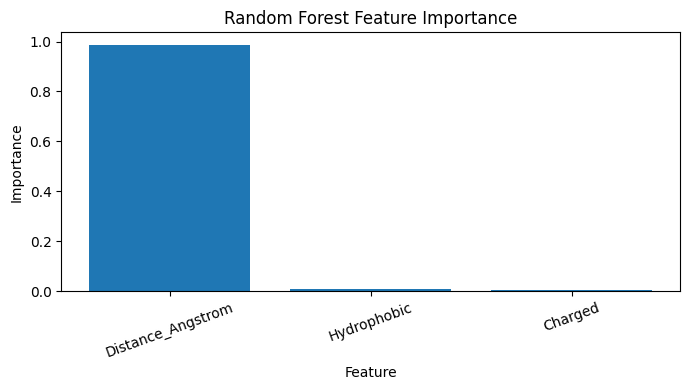

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print("Feature Importance:")
display(feature_importance)

plt.figure(figsize=(7, 4))
plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [21]:
all_interaction_df.to_csv(
    "protein_ligand_interactions.csv",
    index=False
)

print("Saved: protein_ligand_interactions.csv")

Saved: protein_ligand_interactions.csv


In [22]:
from google.colab import files

files.download("protein_ligand_interactions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>